<a href="https://colab.research.google.com/github/UNICAMP-EA979/2026s1-pi04-filtragem-g248527/blob/main/Atividade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Giancarlo Bonvenuto

RA: 248527

Curso: Eng. Computação AB



# Ex04 - Filtragem de Imagens

Nesta atividade vamos entender a operação de convolução e o uso da mesma para filtragem de imagens. Testaremos o uso de **filtros suavizantes**, usados para a remoção de ruído, e **filtros aguçantes**, usados para detecção de bordas.  

- **Filtros suavizantes:** são aqueles que removem a nitidez da imagem fazendo uma média, aritmética ou ponderada, na janela do núcleo. O filtro ponderado suavizante mais comum é o da gaussiana. Filtros suavizantes são muito utilizados para eliminar ruído de uma imagem.

- **Filtros aguçantes:** são aqueles que realçam as bordas da imagem. Alguns dos filtros aguçantes comuns são: Filtro de Sobel, Filtro de Prewitt, Filtro Laplaciano.

Veja mais no notebook sobre [Filtragem no domínio espacial](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/07_Filtragem_no_dominio_espacial.ipynb)

In [104]:
# Importando as bibliotecas que serão utilizadas
import os
import random
import shutil

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

Download das imagens:

In [105]:
zip_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/FiltragemDeImagens.zip"

if not os.path.exists("FiltragemDeImagens.zip"):
    response = requests.get(zip_url)
    with open("FiltragemDeImagens.zip", mode="wb") as file:
        file.write(response.content)

if not os.path.exists("FiltragemDeImagens"):
    shutil.unpack_archive("FiltragemDeImagens.zip")

In [106]:
path = "FiltragemDeImagens/"

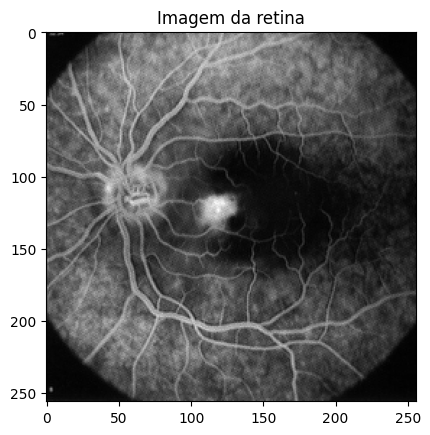

In [107]:
%matplotlib inline
f = mpimg.imread(path+'retina.tif')
plt.title('Imagem da retina')
plt.imshow(f,cmap='gray')

**ATENÇÃO** - as operações de filtragem alteram os valores e eles podem sair da faixa de 0 a 255. Portanto, fique atento à maneira como você está realizando as operações e visualizando os resultados. Algumas dicas:

- Uma boa prática é realizar as operações em ponto flutuante;
- Quando a visualização não corresponde ao esperado, desconfie que os valores sairam da escala e que os valores, de alguma maneira, estão sendo truncados.

## Parte 1 - Operação de convolução e filtro da média

### Exercício 1.1

Entenda o uso da operação de convolução e experimente usá-la para entender o filtro da média. Siga o seguinte roteiro:
- Crie uma imagem numérica pequena (7x7, por exemplo), crie um filtro de média (kernel 3x3) e use a função **convolve()** da biblioteca **scipy.ndimage** para realizar a filtragem. Verifique numericamente que a filtragem está correta;
- Repita a operação de filtragem na imagem da retina e visualize o resultado;
- Faça experimentos com a imagem da retina variando o tamanho do filtro e compare as imagens resultantes;
- Não se esqueça de comentar os métodos utilizados e resultados obtidos.

Imagem numérica 7x7
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Kernel de Blur 3x3
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Aplicando o filtro na imagem numérica
[[0.04938272 0.07407407 0.04938272]
 [0.07407407 0.11111111 0.07407407]
 [0.04938272 0.07407407 0.04938272]]


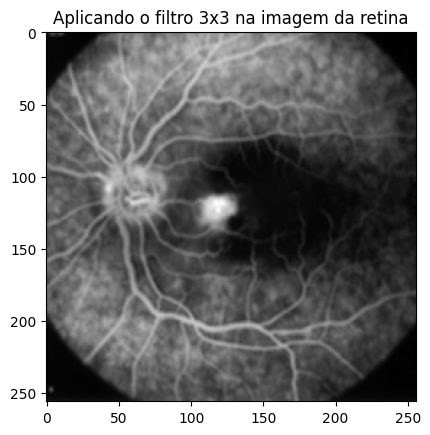

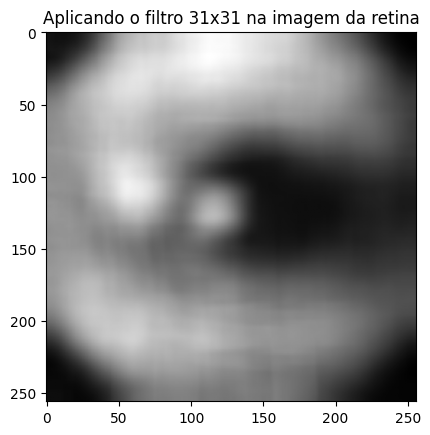

In [108]:
# Imagem feita por uns, vamos fazer a média deles

from scipy.ndimage import convolve

# A image 7x7 é uma array com o fundo preenchido com zeros e um quadrado no meio
img_7x7 = np.zeros((7,7))
img_7x7[2:5,2:5] = 1

print("Imagem numérica 7x7")
print(img_7x7)

kernel_3x3 = np.array([[1/9]*3]*3)
print("Kernel de Blur 3x3")
print(kernel_3x3)

conv_result = convolve(kernel_3x3, kernel_3x3, mode='constant', cval=0)
print("Aplicando o filtro na imagem numérica")
print(conv_result)

f_conv_3x3 = convolve(f.astype(float), kernel_3x3, mode='reflect')
plt.imshow(f_conv_3x3,cmap='gray')
plt.title("Aplicando o filtro 3x3 na imagem da retina")
plt.show()

kernel_31x31  = np.array([[1/(31*31)]*31]*31)
f_conv_31x31 = convolve(f.astype(float), kernel_31x31, mode='reflect')
plt.imshow(f_conv_31x31,cmap='gray')
plt.title("Aplicando o filtro 31x31 na imagem da retina")
plt.show()

### Exercício 1.2

Repita a operação de filtragem, desta vez variando também o modo de tratamento de borda da função **convolve()** - '*reflect*', '*constant*', '*nearest*', '*mirror*', '*wrap*' - explicando as diferenças encontradas. Dica, você só conseguirá visualizar as diferenças se aumentar o tamanho da máscara (filtro).

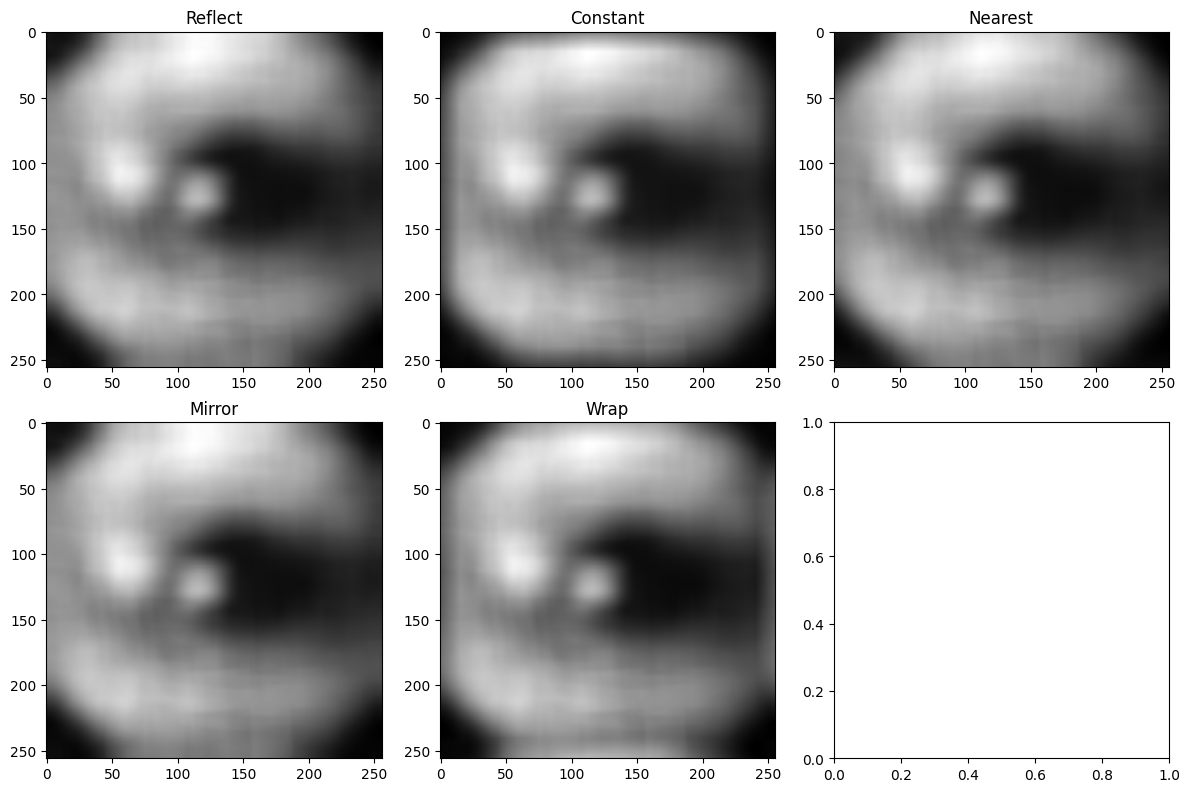

In [109]:
f_conv_reflect = convolve(f.astype(float), kernel_31x31, mode='reflect')
f_conv_constant = convolve(f.astype(float), kernel_31x31, mode='constant', cval=0)
f_conv_nearest = convolve(f.astype(float), kernel_31x31, mode='nearest')
f_conv_mirror = convolve(f.astype(float), kernel_31x31, mode='mirror')
f_conv_wrap = convolve(f.astype(float), kernel_31x31, mode='wrap')

fig, axs = plt.subplots(2,3, figsize=(12, 8)) # Adjusted figsize for better display with 2 rows
# plt.tight_layout() is better placed after all plots are defined to adjust spacing

plt.subplot(231)
plt.imshow(f_conv_reflect, cmap='gray')
plt.title('Reflect')

plt.subplot(232)
plt.imshow(f_conv_constant,cmap='gray')
plt.title('Constant')

plt.subplot(233)
plt.imshow(f_conv_nearest,cmap='gray')
plt.title('Nearest');

plt.subplot(234)
plt.imshow(f_conv_mirror,cmap='gray')
plt.title('Mirror')

plt.subplot(235)
plt.imshow(f_conv_wrap,cmap='gray')
plt.title('Wrap')

plt.tight_layout()

## Parte 2 - Filtro gaussiano e redução de ruído

### Exercício 2.1

Teste a propriedade de decomposição das máscaras da convolução, ou seja, crie um filtro gaussiano bi-dimensional (3,3) a partir de 2 filtros unidimensionais (3,1) e (1,3). Crie também o filtro bi-dimensional diretamente e cheque se os resultados são equivalentes. Comente os métodos utilizados.

In [110]:
# Cria 2 filtros unidimensionais do filtro gaussiano
def criar_gaussiano_separado(tamanho: int, sigma: float):
  if tamanho % 2 == 0:
    raise ValueError("O tamanho do kernel deve ser ímpar.")

  # Aqui seguimos a fórmulados slides
  x = np.linspace(-(tamanho-1)/2, (tamanho-1)/2, tamanho, dtype=np.int32)
  gaussiano = np.exp(-x**2/(2*sigma**2))
  gaussiano = gaussiano / np.sum(gaussiano)
  return gaussiano.reshape((1, tamanho)), gaussiano.reshape((tamanho, 1))



# Kernel gaussiano à mão aproximado (dos slides)
kernel_gaussiano = np.array([
    [1/16, 2/16, 1/16],
    [2/16, 4/16, 2/16],
    [1/16, 2/16, 1/16],
])

x, y = criar_gaussiano_separado(3, 1)
print("kernel_gaussiano")
print(kernel_gaussiano)
print("x")
print(x)
print("y")
print(y)

print("x@y")
print(y@x)

# Verificando se são iguais
print(f" São iguais? {np.allclose(kernel_gaussiano, y@x, atol=1e-6)}")

kernel_gaussiano
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
x
[[0.27406862 0.45186276 0.27406862]]
y
[[0.27406862]
 [0.45186276]
 [0.27406862]]
x@y
[[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]
 São iguais? False


### Exercício 2.2

Teste a aplicação de filtros suavizantes para redução de ruído: Adicione ruído gaussiano à imagem da retina (sugestão: use **np.random**) e depois tente remover o ruído com o filtro da média e com o filtro gaussiano. Você pode aumentar os filtros se quiser. Comente os métodos utilizados e resultados obtidos.

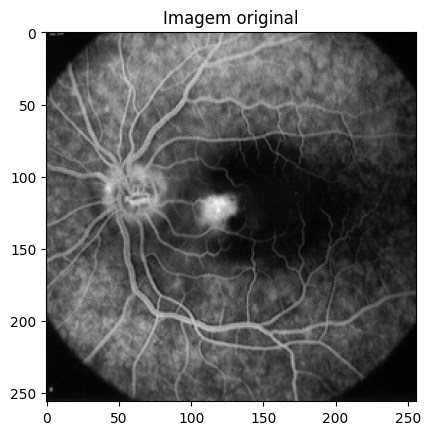

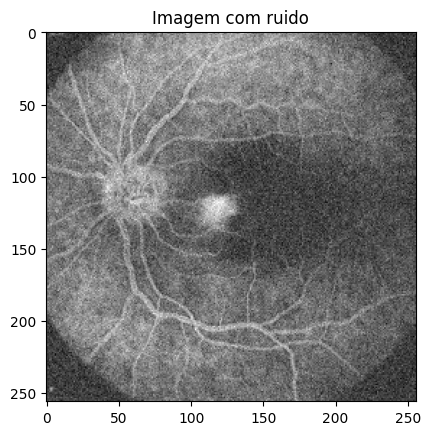

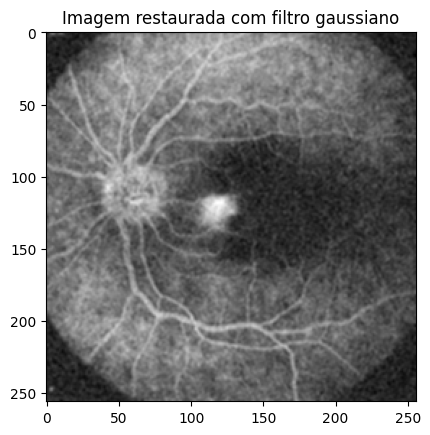

In [111]:
plt.imshow(f,cmap='gray')
plt.title("Imagem original")
plt.show()

ruido = np.random.normal(scale=25, size=f.shape)
f_ruido = f + ruido
plt.imshow(f_ruido,cmap='gray')
plt.title("Imagem com ruido")
plt.show()

x, y = criar_gaussiano_separado(3, 1)

f_restaurado = convolve(f_ruido.astype(float), x, mode='reflect')
f_restaurado = convolve(f_restaurado, y, mode='reflect')
plt.imshow(f_restaurado,cmap='gray')
plt.title("Imagem restaurada com filtro gaussiano")
plt.show()

## Parte 3 - Filtro de Sobel e detecção de bordas

Existem vários filtros que procuram realçar as bordas da imagem. Um dos mais conhecidos é o Operador Sobel, composto por uma máscara vertical (Sv) e uma máscara horizontal (Sh).

In [112]:
Sv = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
print('Sv =\n',Sv)

Sh = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
print('Sh =\n',Sh)

Sv =
 [[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Sh =
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


Para detectar bordas de uma imagem usando o Filtro de Sobel, precisamos fazer a filtragem da imagem usando tanto a máscara vertical, quanto a horizontal. No final, acabaremos com 2 imagens resultantes, uma reforçando as bordas verticais e outra reforçando as bordas horizontais, como exemplificado abaixo.

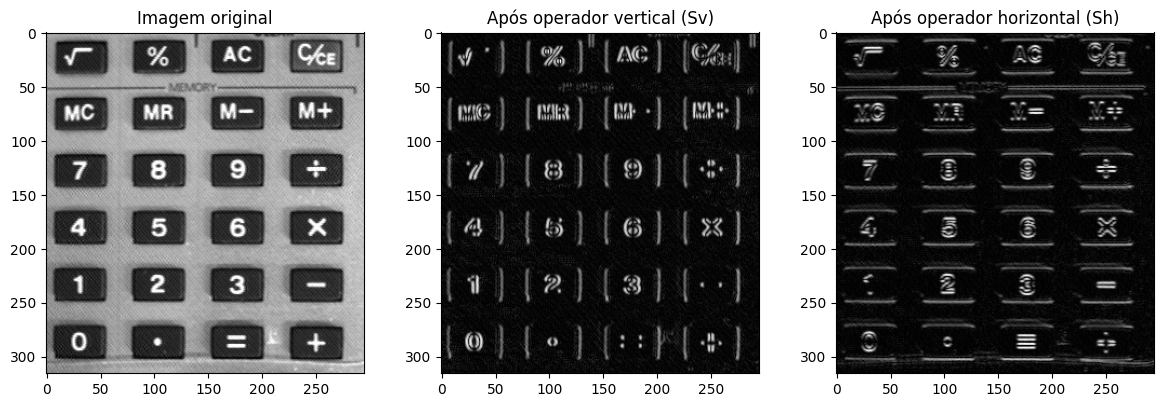

In [113]:
img = mpimg.imread(path+'keyb.tif')
img_sv = mpimg.imread(path+'keyb_sv.tif')
img_sh = mpimg.imread(path+'keyb_sh.tif')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img_sv,cmap='gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img_sh,cmap='gray')
plt.title('Após operador horizontal (Sh)');

### Exercício 3.1 - Visualizando as bordas verticais e horizontais em 2 imagens separadas

Experimente filtrar as imagens abaixo com os Filtros de Sobel vertical e horizontal e visualize o resultado. Para cada imagem, você deve obter uma imagem fitrada pelo Filtro de Sobel vertical - **fv** - e uma imagem filtrada pelo Filtro de Sobel horizontal - **fh**. Comente sobre os resultados obtidos. As imagens geradas estão de acordo com o exemplo apresentado para a imagem da calculadora? Em caso negativo, explique o porquê e tente fazer com que as imagens fiquem mais semelhantes.

In [114]:
img1 = mpimg.imread(path+'retina.tif')

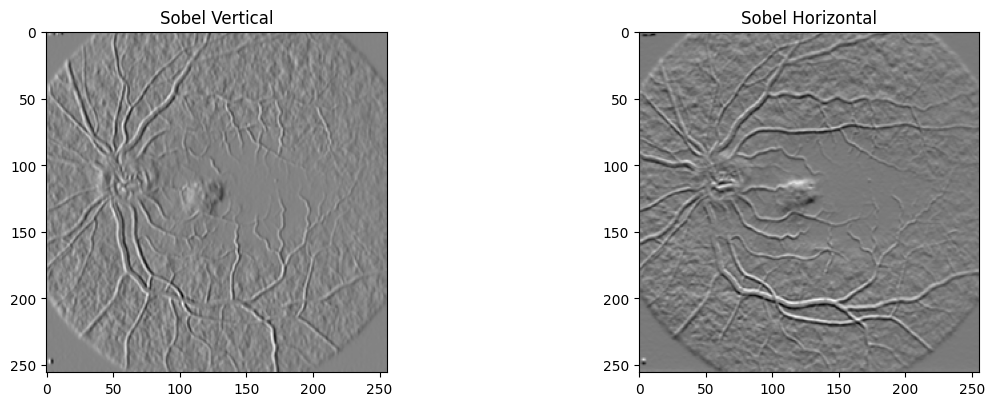

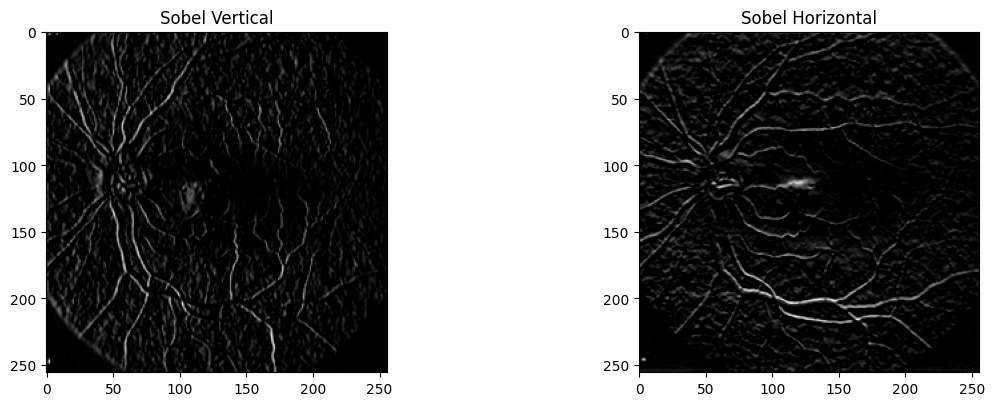

In [118]:
img1_sv = convolve(img1.astype(float), Sv, mode='reflect')
img1_sh = convolve(img1.astype(float), Sh, mode='reflect')

fig, axs = plt.subplots(1,2, figsize=(12, 4))
plt.tight_layout()

plt.subplot(121)
plt.imshow(img1_sv, cmap='gray')
plt.title('Sobel Vertical')

plt.subplot(122)
plt.imshow(img1_sh,cmap='gray')
plt.title('Sobel Horizontal');

img1_sv_non_neg = np.clip(img1_sv, 0, None)
img1_sh_non_neg = np.clip(img1_sh, 0, None)

fig, axs = plt.subplots(1,2, figsize=(12, 4))
plt.tight_layout()

plt.subplot(121)
plt.imshow(img1_sv_non_neg, cmap='gray')
plt.title('Sobel Vertical')

plt.subplot(122)
plt.imshow(img1_sh_non_neg,cmap='gray')
plt.title('Sobel Horizontal');


---

In [ ]:
img2 = mpimg.imread(path+'cameraman.tif')

In [ ]:
# Seu código aqui

### Exercício 3.2 - Visualizando todas as bordas em uma única imagem

Para visualizar o resultado das 2 filtragens (horizontal e vertical) em uma única imagem, utilizamos a magnitude de Sobel. A função MagSobel (a ser implementada) possui como parâmetro a imagem de entrada e deve seguir a seguinte equação:

$$MagSobel = \sqrt{f_h^2 + f_v^2}$$

onde $f_h$ é a imagem de entrada convolvida com o operador de Sobel horizontal e $f_v$ é a imagem de entrada convolvida com o operador de Sobel vertical. Crie esta função e visualize a Magnitude de Sobel das imagens utilizadas no exercício 3.1.

In [ ]:
# Seu código aqui

## Parte 4 - Aprendendo filtros com CNN (opcional para EA979)

Como vimos em sala de aula, as redes neurais convolucionais (CNNs, do inglês *convolutional neural networks*) têm como base as camadas convolucionais, um banco de filtros cujos pesos são aprendidos a partir de um gabarito para predição. Para entender melhor como isso funciona, vamos praticar com redes convolucionais bem simples e visualizar como os filtros são aprendidos por elas.

Vamos utilizar um conjunto de dados composto por 60 imagens de cidades, que servirão como entradas para a nossa rede. Além das imagens originais, temos também outros dois conjuntos de imagens, obtidos após a aplicação de dois tipos de filtros diferentes nas imagens originais (Dica: ambos os filtros aplicados foram filtros vistos anteriormente neste notebook). Essas imagens filtradas servirão como nosso gabarito para que a CNN possa aprender automaticamente qual filtro foi aplicado em cada conjunto de dados, ou seja, a rede vai tentar aprender qual o filtro necessário para obter o gabarito (imagem filtrada) a partir da entrada (imagem original).

**Para mais informações sobre redes convolucionais, exemplos e boas práticas, verifique os materiais de apoio disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub. Recomendamos utilizar a biblioteca PyTorch, que será utilizada novamente em exercícios futuros.**

Abaixo, visualizamos uma imagem aleatória do conjunto e suas respectivas versões filtradas.

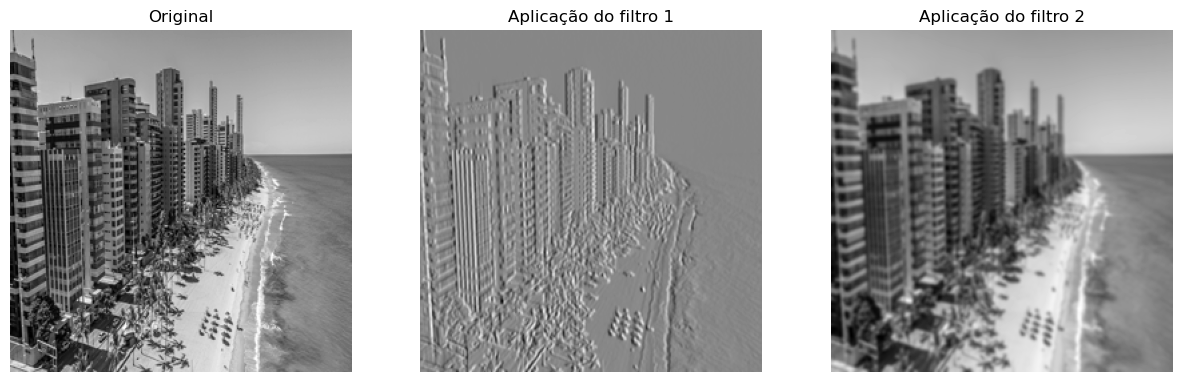

In [ ]:
path_dataset = path + 'City_images/'
selec_img = random.randint(1, 60)

img_ori = Image.open(path_dataset+'imgs_originais/'+f'{selec_img}.tif')
img_f1 = Image.open(path_dataset+'imgs_filt1/'+f'{selec_img}.tif')
img_f2 = Image.open(path_dataset+'imgs_filt2/'+f'{selec_img}.tif')

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(np.array(img_ori), cmap='gray')
plt.axis('off')
plt.title('Original')
plt.subplot(132)
plt.imshow(np.array(img_f1), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 1')
plt.subplot(133)
plt.imshow(np.array(img_f2), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 2');

Para facilitar a visualização dos filtros aprendidos pela rede, vamos utilizar o código abaixo, que gera um **gif** a partir de um conjunto de arrays. Tente entender o código a partir do exemplo dado.

In [ ]:
# Criando um conjunto de arrays para exemplificar o código
array_list = []
array_inicial = np.array([[0,0,0,0,0,0,0,0,0,0,0,0]]*6, dtype='uint8')
array_list.append(array_inicial)
for i in range(12):
    tmp = array_inicial.copy()
    tmp[2:4,:i+1] = 1
    array_list.append(tmp)

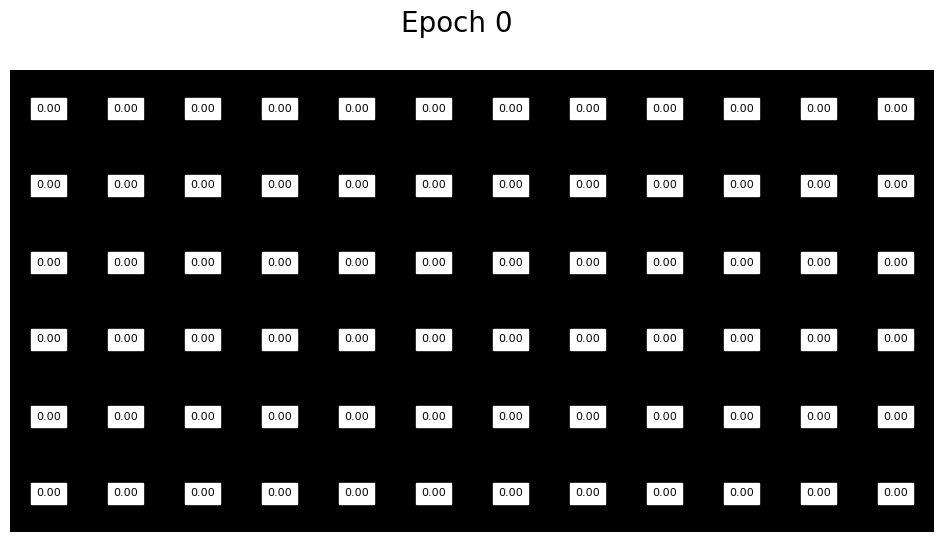

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Gif generation
images = np.array(array_list)
vmin = images.min()
vmax = images.max()
fig = plt.figure(figsize=(12,6))

# Function to update the image and add text annotations
def update(frame):
    plt.clf()  # Clear the previous plot
    fig.suptitle("Epoch {}".format(frame), fontsize=20) # Define the title
    plt.imshow(images[frame], vmin=vmin, vmax=vmax, cmap='gray') # Generate the image
    plt.axis('off')
    # Add text annotations
    for (i, j), value in np.ndenumerate(images[frame]):
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8, backgroundcolor='white')

# Creating the animation
anim = FuncAnimation(fig, update, frames=len(images), interval=200)
# Displaying the animation in the notebook
html = anim.to_jshtml()
HTML(html)

### Exercício 4.1

Crie uma CNN composta por apenas uma camada convolucional com kernel de tamanho 3x3, que utilize as imagens originais como entrada e tenha como "gabarito" o primeiro conjunto de imagens filtradas (**imgs_filt1**). Você precisará definir uma função de loss, um otimizador para a rede e o número de épocas para treinamento. Então, treine a rede com as imagens especificadas, acompanhando os valores de loss a cada época. Você deve armazenar em uma lista os pesos do kernel da rede a cada época do treinamento.

Após o treinamento, visualize a progressão dos pesos do kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir do **gif** obtido, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt1**?

In [ ]:
# Seu código aqui

### Exercício 4.2

Repita o processo realizado no exercício 5.1, mas dessa vez crie uma CNN composta por duas camadas convolucionais, a primeira com kernel de tamanho 1x5 e a segunda com kernel de tamanho 5x1. Você deve utilizar como "gabarito" o segundo conjunto de imagens filtradas (**imgs_filt2**). Armazene os pesos dos kernels da rede a cada época do treinamento em duas listas, uma para cada kernel.

Após o treinamento, visualize a progressão dos pesos de cada kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir dos **gifs** obtidos, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt2**?

In [ ]:
# Seu código aqui